In [58]:
import numpy as np
import json
from pathlib import Path
from matplotlib import pyplot as plt


In [59]:
logs_dir = Path("train_logs")

#log_name = "TransformerBottleneck-model_preactivation_verynoisy_kernel_5_bce_50.json"
log_name = "TransformerBottleneck-model_levels_3_kernel_5.json"

with open(logs_dir / log_name, 'r', encoding='utf-8') as f:
    train_log = json.load(f)["train_log"]

In [60]:
epoch = [x['epoch'] for x in train_log]
lr    = [x['lr'] for x in train_log]
train_loss = [x['train_loss'] for x in train_log]
train_dice = [x['train_dice'] for x in train_log]
test_loss = [x['test_loss'] for x in train_log]
test_dice = [x['test_dice'] for x in train_log]

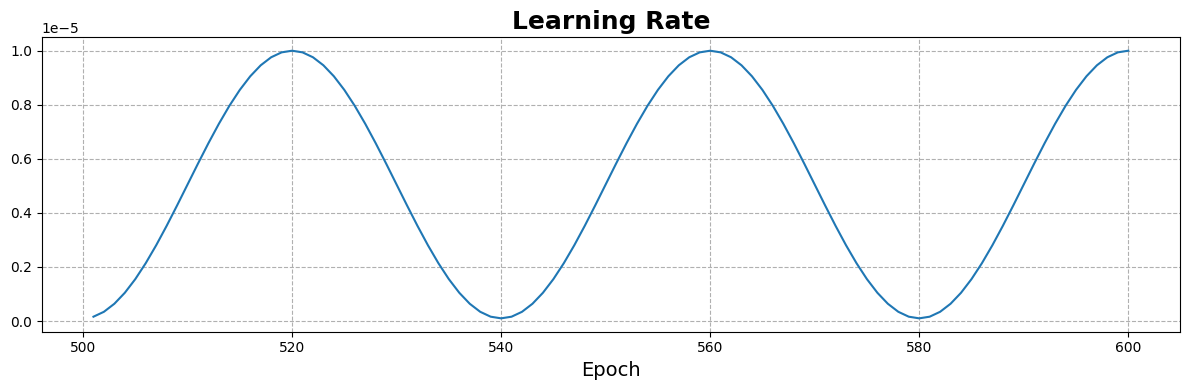

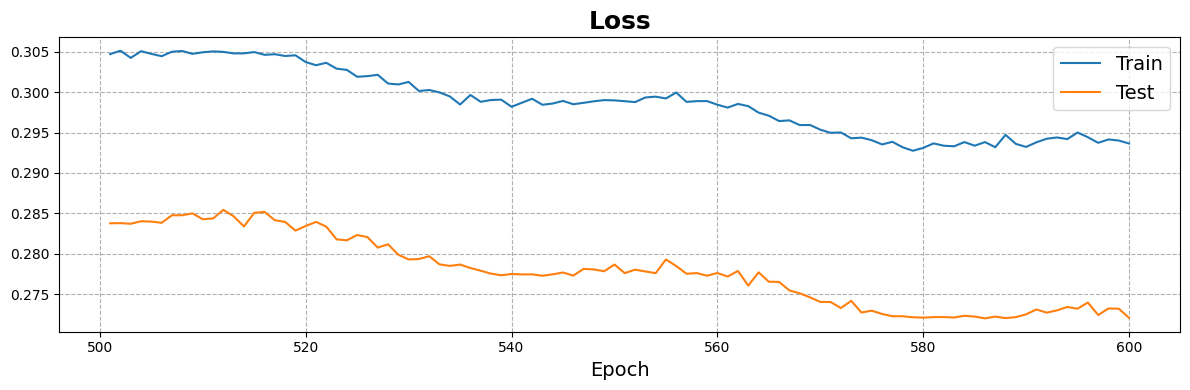

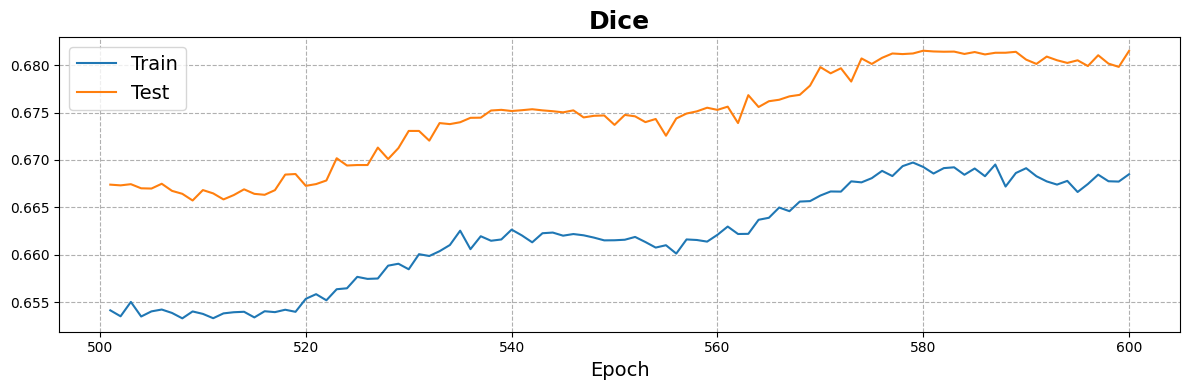

In [62]:
plot_titles = [
    'Learning Rate',
    'Loss',
    'Dice',
]
#x_slice = slice(0,-1)
x_slice = slice(500,600)
for idx, var in enumerate([lr, [train_loss, test_loss], [train_dice, test_dice]]):
    plt.figure(figsize=(12,4))
    if idx == 0:
        plt.plot(epoch[x_slice], var[x_slice])
    else:
        plt.plot(epoch[x_slice], var[0][x_slice], label='Train')
        plt.plot(epoch[x_slice], var[1][x_slice], label='Test')
        plt.legend(fontsize=14)
    plt.grid(axis='both', linestyle='--')
    plt.xlabel('Epoch', fontsize=14)
    plt.title(plot_titles[idx], fontweight='bold', fontsize=18)
    
    plt.tight_layout()
    plt.show()